<a href="https://colab.research.google.com/github/stackparth/Credit_Card_Fraud/blob/main/credit_card_fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [28]:
# Load dataset
df = pd.read_csv("creditcard.csv")
print(df.head)

<bound method NDFrame.head of         Time        V1        V2        V3        V4        V5        V6  \
0          0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388   
1          0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361   
2          1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499   
3          1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4          2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921   
...      ...       ...       ...       ...       ...       ...       ...   
27814  34711  1.443955 -1.052462 -0.141721 -1.564017 -0.966274 -0.333886   
27815  34711 -0.263364  0.931818  1.193111 -0.507924  0.862019  0.249381   
27816  34712  0.976345 -1.024867  0.978714  0.639442 -1.413711  0.311635   
27817  34712  1.464604 -0.437919 -0.018869 -1.057177 -0.154243  0.251215   
27818     34       NaN       NaN       NaN       NaN       NaN       NaN   

             V7        V8        V9  ...       V21       

In [29]:
print("Shape of dataset:")
print(df.shape)

Shape of dataset:
(27819, 31)


In [30]:
# Check null values
print("Null values before cleaning:")
print(df.isnull().sum())

# Drop null values
df = df.dropna()

Null values before cleaning:
Time      0
V1        1
V2        1
V3        1
V4        1
V5        1
V6        1
V7        1
V8        1
V9        1
V10       1
V11       1
V12       1
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [31]:
# Check again
print("\nNull values after cleaning:")
print(df.isnull().sum())


Null values after cleaning:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [32]:
print("\nClass Distribution:")
print(df["Class"].value_counts())

print("\nClass Distribution (%):")
print(df["Class"].value_counts(normalize=True) * 100)


Class Distribution:
Class
0.0    27725
1.0       93
Name: count, dtype: int64

Class Distribution (%):
Class
0.0    99.665684
1.0     0.334316
Name: proportion, dtype: float64


In [33]:
# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]
print("\nFeature Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)


Feature Shape:
(27818, 30)

Target Shape:
(27818,)


In [35]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
# Scale data for SVM
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
# Apply SMOTE only to training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0.0    22180
1.0       74
Name: count, dtype: int64

After SMOTE:
Class
0.0    22180
1.0    22180
Name: count, dtype: int64


In [38]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train_smote, y_train_smote)

# Fraud probability
y_prob = model.predict_proba(X_test_scaled)[:, 1]
print("\nFirst 10 probabilities:")
print(y_prob[:10])

print("\nProbability Information:")

print(
    "Minimum probability:",
    y_prob.min()
)

print(
    "Maximum probability:",
    y_prob.max()
)

print(
    "Mean probability:",
    y_prob.mean()
)


# Threshold tuning
threshold = 0.30

y_pred = (y_prob >= threshold).astype(int)

print("\nXGBoost Results")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))


First 10 probabilities:
[1.5495533e-04 6.2091873e-05 5.5627475e-05 1.9196668e-04 4.4291162e-05
 8.5532625e-04 5.2585336e-05 5.0362778e-05 6.6912573e-05 3.3041660e-04]

Probability Information:
Minimum probability: 1.7705728e-05
Maximum probability: 0.99991536
Mean probability: 0.004036982

XGBoost Results
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5545
         1.0       0.76      0.84      0.80        19

    accuracy                           1.00      5564
   macro avg       0.88      0.92      0.90      5564
weighted avg       1.00      1.00      1.00      5564

Confusion Matrix:
[[5540    5]
 [   3   16]]
ROC-AUC: 0.9949124388970624


In [39]:
for threshold in [0.1, 0.2, 0.3, 0.4, 0.5]:

    pred = (y_prob >= threshold).astype(int)

    print(
        threshold,
        "Precision:", precision_score(y_test, pred),
        "Recall:", recall_score(y_test, pred),
        "F1:", f1_score(y_test, pred)
    )

0.1 Precision: 0.68 Recall: 0.8947368421052632 F1: 0.7727272727272727
0.2 Precision: 0.7727272727272727 Recall: 0.8947368421052632 F1: 0.8292682926829268
0.3 Precision: 0.7619047619047619 Recall: 0.8421052631578947 F1: 0.8
0.4 Precision: 0.75 Recall: 0.7894736842105263 F1: 0.7692307692307693
0.5 Precision: 0.7894736842105263 Recall: 0.7894736842105263 F1: 0.7894736842105263


In [40]:
svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm.fit(X_train_smote, y_train_smote)

svm_prob = svm.predict_proba(X_test_scaled)[:, 1]

svm_pred = (svm_prob >= 0.5).astype(int)

print("\nSVM Results")
print(classification_report(y_test, svm_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

print("ROC-AUC:", roc_auc_score(y_test, svm_prob))


SVM Results
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00      5545
         1.0       0.27      0.84      0.41        19

    accuracy                           0.99      5564
   macro avg       0.63      0.92      0.70      5564
weighted avg       1.00      0.99      0.99      5564

Confusion Matrix:
[[5501   44]
 [   3   16]]
ROC-AUC: 0.9533814247069431



Top Features:
V14       0.728435
V12       0.049636
Amount    0.044740
V4        0.042315
V3        0.015080
V2        0.012961
Time      0.009057
V11       0.008864
V7        0.008683
V19       0.008384
dtype: float32


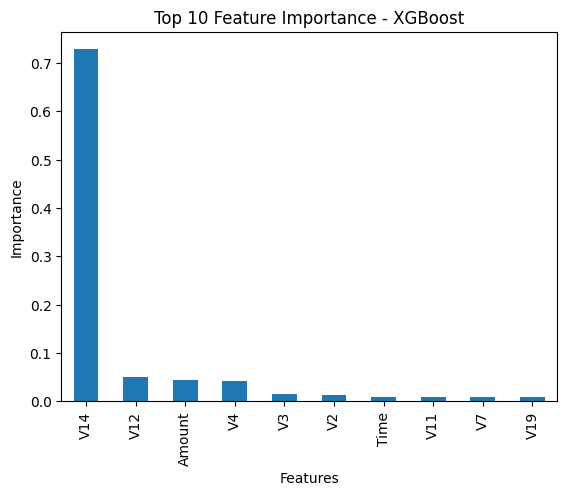

In [41]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop Features:")
print(importance.head(10))

importance.head(10).plot(kind="bar")

plt.title("Top 10 Feature Importance - XGBoost")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()